In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import convolve

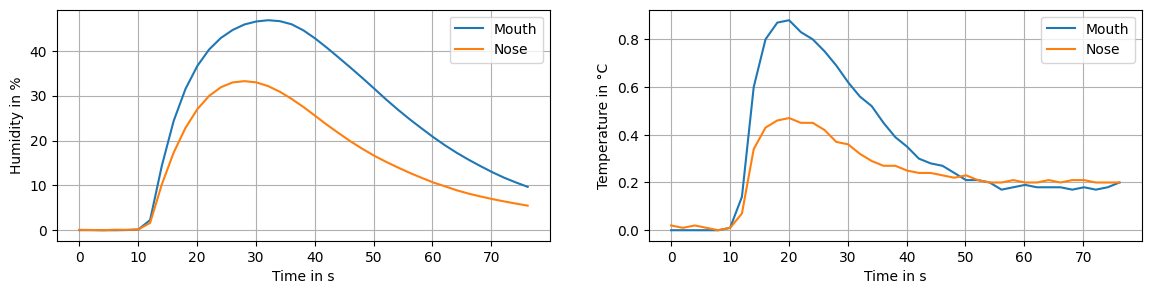

In [2]:
def get_cir(region):
    # load data
    data_all = []
    for i in range(1, 11):
        data = np.loadtxt(f'{os.path.abspath(os.path.join(os.getcwd(), os.pardir))}/data/cir/{region}_trial_{i}.dat', delimiter=',', skiprows=1)
        data_all.append(data)

    # mean over trials
    cir_mean = np.mean(data_all, axis=0)

    # baseline correction
    baseline_humidity = np.min(cir_mean[:, 1])
    baseline_temperature = np.min(cir_mean[:, 2])
    cir_mean[:, 1] -= baseline_humidity
    cir_mean[:, 2] -= baseline_temperature

    return cir_mean[:, 0]/1000, cir_mean[:, 1], cir_mean[:, 2]

# get cir
t, cir_mouth_humidity, cir_mouth_temperature = get_cir('mouth')
t, cir_nose_humidity, cir_nose_temperature = get_cir('nose')
# plotting
fig, ax = plt.subplots(1, 2, figsize=(14, 3))
ax[0].plot(t, cir_mouth_humidity, label='Mouth')
ax[0].plot(t, cir_nose_humidity, label='Nose')
ax[0].set_xlabel('Time in s')
ax[0].set_ylabel('Humidity in %')
ax[0].grid()
ax[0].legend()

ax[1].plot(t, cir_mouth_temperature, label='Mouth')
ax[1].plot(t, cir_nose_temperature, label='Nose')
ax[1].set_xlabel('Time in s')
ax[1].set_ylabel('Temperature in °C')
ax[1].grid()
ax[1].legend()
plt.show()

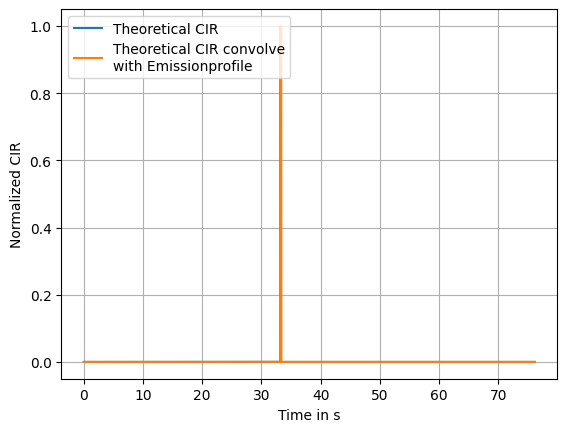

In [ ]:
def theoretical_cir(t, t0, M, D, d, v):
    tp = np.maximum(t - t0, 1e-6)
    return M / np.sqrt(4 * np.pi * D * tp) * np.exp(-(v * tp - d)**2 / (4 * D * tp))

def emission(t, T, q):
    return np.where((t >= 0) & (t <= T), q, 0.0)

# normalize cir
cir_mouth_humidity_norm = cir_mouth_humidity / np.max(cir_mouth_humidity)
cir_mouth_temperature_norm = cir_mouth_temperature / np.max(cir_mouth_temperature)
cir_nose_humidity_norm = cir_nose_humidity / np.max(cir_nose_humidity)
cir_nose_temperature_norm = cir_nose_temperature / np.max(cir_nose_temperature)

# get x-axis offset
peak_idx = np.argmax(cir_mouth_humidity_norm)
t0 = t[peak_idx]

# upsample time vector
t_upsampled = np.linspace(t.min(), t.max(), 100000)

# params used from Tab. I in "Channel and Noise Models for Nonlinear Molecular  Communication Systems"
D = 0.0959          # Diffusion coefficient [cm^2/s]
d = 225             # Distance Tx-Rx [cm]
v = 190             # velocity towards sensor [cm/s]
M = 1               # Molecules emitted

# theoretical cir
cir_theoretical = theoretical_cir(t_upsampled, t0, M, D, d, v)
cir_theoretical_norm = cir_theoretical / np.max(cir_theoretical)

# emission profile
emission_profile = emission(t_upsampled, T=100e-3, q=M)

# convolve emission with cir
cir_convolved = convolve(emission_profile, cir_theoretical, mode='full')[:len(t_upsampled)] * (t_upsampled[1] - t_upsampled[0])
cir_convolved /= np.max(cir_convolved)

# plotting
plt.figure()
plt.plot(t_upsampled, cir_theoretical_norm, label='Theoretical CIR')
plt.plot(t_upsampled, cir_convolved, label='Theoretical CIR convolve\nwith Emissionprofile')
plt.xlim(33, 33.5)
plt.xlabel('Time in s')
plt.ylabel('Normalized CIR')
plt.grid()
plt.legend(loc='upper left')
plt.show()

Fitted parameters: a=5.8915, b=0.0026, c=4.4811, d=157.1786


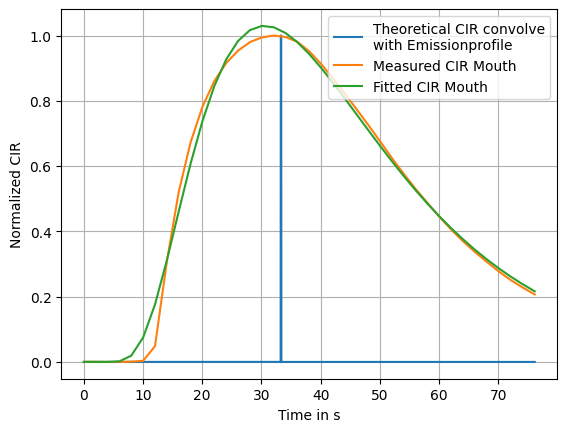

In [13]:
def fit_cir(t, a, b, c, d):
    return a / np.sqrt(t) * np.exp(-b * (d - c * t)**2 / t)

a0 = cir_mouth_humidity_norm[peak_idx]*np.sqrt(t[peak_idx])
initial_guess = [a0, 1e-4, 54, 190]
lower_bound, upper_bound = [0, 0, 0, 0], [np.inf, np.inf, np.inf, np.inf]
popt, pcov = curve_fit(fit_cir, t, cir_mouth_humidity_norm, p0=initial_guess, bounds=(lower_bound, upper_bound))
print(f"Fitted parameters: a={popt[0]:.4f}, b={popt[1]:.4f}, c={popt[2]:.4f}, d={popt[3]:.4f}")

plt.figure()
plt.plot(t_upsampled, cir_convolved, label='Theoretical CIR convolve\nwith Emissionprofile')
plt.plot(t, cir_mouth_humidity_norm, label='Measured CIR Mouth')
plt.plot(t, fit_cir(t, *popt), label='Fitted CIR Mouth')
plt.xlabel('Time in s')
plt.ylabel('Normalized CIR')
plt.grid()
plt.legend()
plt.show()